In [2]:
import matplotlib.pyplot as plt

from draw_rna.wrapper_functions import create_figure, ct_to_paired_list_count_all, get_structure_depth, print_energy_list, get_energy_list
%load_ext autoreload
%autoreload 2   

In [7]:
files = [
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/2.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/3.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/4.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/5.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/6.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/7.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/trRNA-SS.dt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt',
    '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/RNAstructure.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/vsfold5.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/probknot.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure1_from_ct.dt',
    # '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure2_from_ct.dt',
]

In [11]:
fake = [
    [(130,4)],
    [(114,1)],
    [(130,6)],
    [(140,3)],
    [],
    [],
    [(45,1),(114,2),(120,2),(154,2)],
]
for idx, file in enumerate(files):
    base_loop = 0
    final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
    depth = get_structure_depth(structures)
    output_path = file.replace('dots', 'figures').replace('.dt', '.png')
    # print(f"free bases, {structures[-1][0]} nm: {structures[-1][0] * 0.59}")
    # continue
    x = 0
    for x, y in zip(sorted(depth)[:-1], sorted(depth)[1:]):
        if x == y: break
    print(f"Base loop for {file.split('/')[-1]} \nfree bases\t{structures[-1][0]}\t{structures[-1][0] * 0.59:.2f}")
    # gives unfoldings till fist junction
    # for idy, (s, d) in enumerate(zip(reversed(structures), reversed(depth))):
    #     if d > x: break
    #     base_loop += 2*len(s[:-1])+s[-1]
    #     print(f"Step {idy}\t{base_loop}\t{round(base_loop*.59, 2)}")
    total_bases = 0
    for idy, (s, d) in enumerate(zip(structures, depth)):
        if d == 0:
            print(f"Length of total segment bp:\t{total_bases+s[-1]+(2*(len(s)-1))}\t{(total_bases+s[-1]+(2*(len(s)-1)))*.59:.2f}")
            total_bases = 0
            continue
        total_bases += s[-1]+(2*(len(s)-1))

Base loop for CentroidFold.dt 
free bases	29	17.11
Length of total segment bp:	50	29.50
Length of total segment bp:	55	32.45
Length of total segment bp:	13	7.67
Length of total segment bp:	24	14.16
Base loop for orbisims.dt 
free bases	14	8.26
Length of total segment bp:	117	69.03
Length of total segment bp:	25	14.75
Length of total segment bp:	24	14.16


AA /home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt
171
saving svg/pdf as /home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/figures/CentroidFold.png


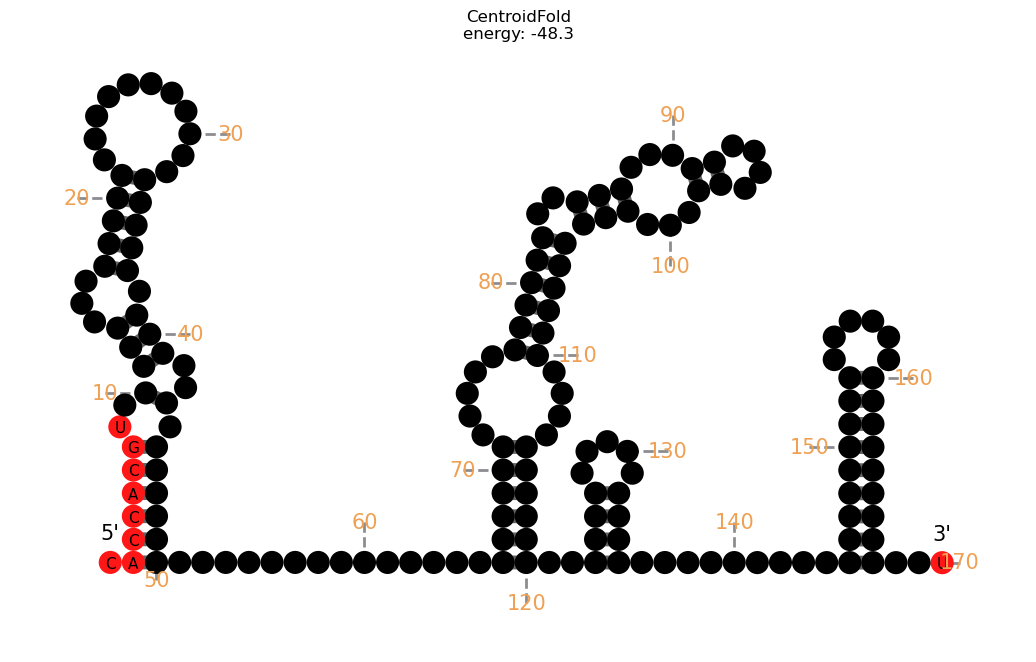


	CentroidFold.dt
17.11	-0.48
AA /home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt
180
saving svg/pdf as /home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/figures/orbisims.png


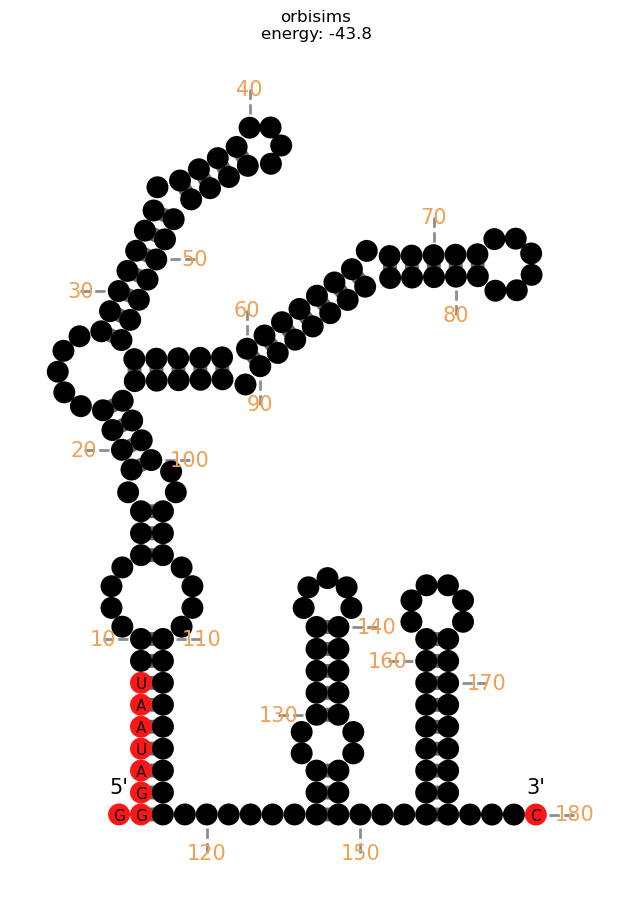


	orbisims.dt
8.26	-0.44


In [20]:
fake = [[] for x in files]
# fake[0] = [(130,4)]
# fake[1] = [(114,1)]
# fake[1] = [(45,10,'('),(120,10,')')]
# fake[2] = [(130,6)]
# fake[3] = [(140,3)]
# fake[6] = [(45,1),(114,2),(120,2),(154,2)]
# fake[-3] = [(114,1)]
# files = ['/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/2.dt']
# fake = [[],]
for file, f in zip(files, fake):
    final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
    depth = get_structure_depth(structures)
    segment = 0
    seg_length = 0
    lines = []
    lines.append(f"\tSegment {segment}")
    for idy, (s, d) in enumerate(zip(structures, depth)):
        seg_length += s[-1]+(2*(len(s)-1))
        lines.append((s[-1]+(2*(len(s)-1)))*0.59)
        if d == 0:
            segment += 1
            seg_length = 0
            lines.append(f"\tSegment {segment}")
    title = (file.split('/')[-1].replace('.dt', ''), 0.5, 0.98)
    output_path = file.replace('dots', 'figures').replace('.dt', '.png')
    colors = ['black' for _ in db]
    # overwrite_colors = ([x for x in range(8)]+[len(db)-1], (255, 22, 22))
    final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
    for x in list(range(8))+[len(db)-1]:
        colors[x] = (255, 22, 22)
    print("AA", file)
    bases, x, final_str_list = create_figure(file, show_energies=False, segment_lenghts=False, energies_individual=False, file_name=output_path, large_mode=True, numbering=10, custom_line=True, store_plt_svg=True, add_fake=f, show_plot=True, title=title, colors=colors)
    plt.close()
    # continue
    print()
    print(f"\t{file.split('/')[-1]}")
    energies, total_energy = get_energy_list(seq, db)
    print(bases+f"\t{total_energy/100:.2f}")
    tmp_values = []
    total = 0
    idx = 0
    if final_str_list:
        for line in lines[:-1]:
            if type(line) is str:
                # print(line)
                if tmp_values:
                    total = 0
                    for l in reversed(tmp_values):
                        total += l[0]
                        print(f"{l[0]:.2f}\t{total:.2f}\t{l[1]}")
                    tmp_values = []
                    total = 0
                print(line)
            else:
                total += line
                tmp_values.append((line, final_str_list[idx][1].split('\n')[-1]))
                idx += 1
            total = 0
        for l in reversed(tmp_values):
            total += l[0]
            print(f"{l[0]:.2f}\t{total:.2f}\t{l[1]}")

energy -57.29999923706055
energy -57.29999923706055


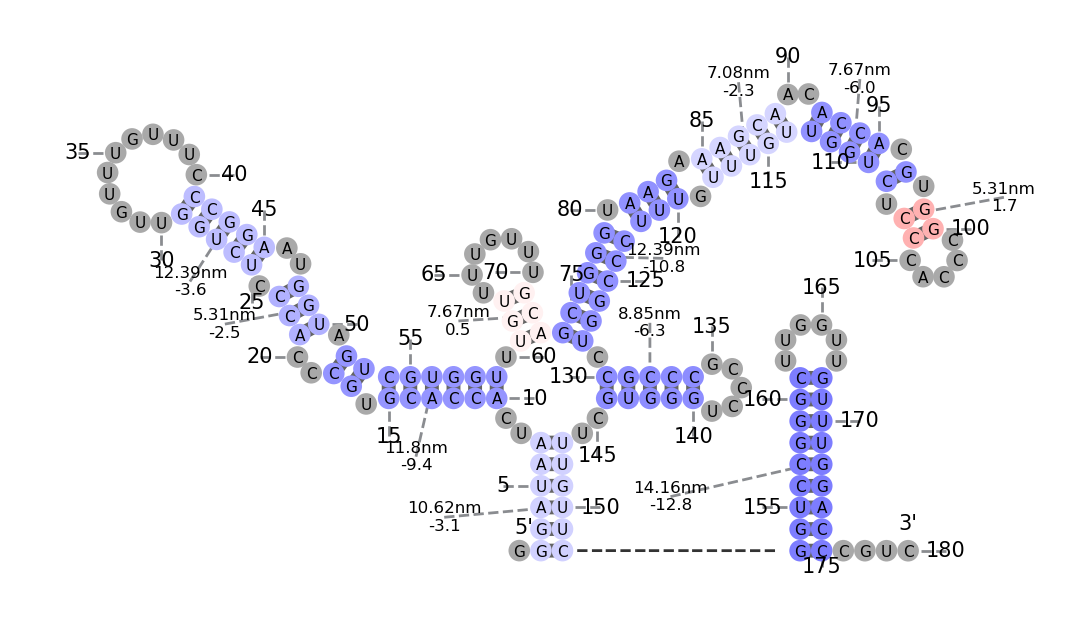


	orbisims.dt
2.95	-57.30
	Segment 0
10.62	10.62	10.62nm
8.85	19.47	8.85nm
12.39	31.86	12.39nm
7.08	38.94	7.08nm
7.67	46.61	7.67nm
5.31	51.92	5.31nm
7.67	59.59	7.67nm
11.80	71.39	11.8nm
5.31	76.70	5.31nm
12.39	89.09	12.39nm
	Segment 1
14.16	14.16	14.16nm


In [40]:
file = files[-1]
f = [(152,10)]
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, predict=True)
depth = get_structure_depth(structures)
segment = 0
seg_length = 0
lines = []
lines.append(f"\tSegment {segment}")
for idy, (s, d) in enumerate(zip(structures, depth)):
    seg_length += s[-1]+(2*(len(s)-1))
    lines.append((s[-1]+(2*(len(s)-1)))*0.59)
    if d == 0:
        segment += 1
        seg_length = 0
        lines.append(f"\tSegment {segment}")
bases, x, y = create_figure(file, predict=True, show_energies=True, energies_individual=False, large_mode=True, numbering=5, custom_line=True, store_plt_svg=False, add_fake=f, show_plot=True)
plt.close()
# continue
print()
print(f"\t{file.split('/')[-1]}")
energies, total_energy = get_energy_list(seq, db)
print(bases+f"\t{total_energy/100:.2f}")
tmp_values = []
total = 0
idx = 0
for line in lines[:-1]:
    if type(line) is str:
        # print(line)
        if tmp_values:
            total = 0
            for l in reversed(tmp_values):
                total += l[0]
                print(f"{l[0]:.2f}\t{total:.2f}\t{l[1]}")
            tmp_values = []
            total = 0
        print(line)
    else:
        total += line
        tmp_values.append((line, final_str_list[idx][1].split('\n')[-1]))
        idx += 1
    total = 0
for l in reversed(tmp_values):
    total += l[0]
    print(f"{l[0]:.2f}\t{total:.2f}\t{l[1]}")

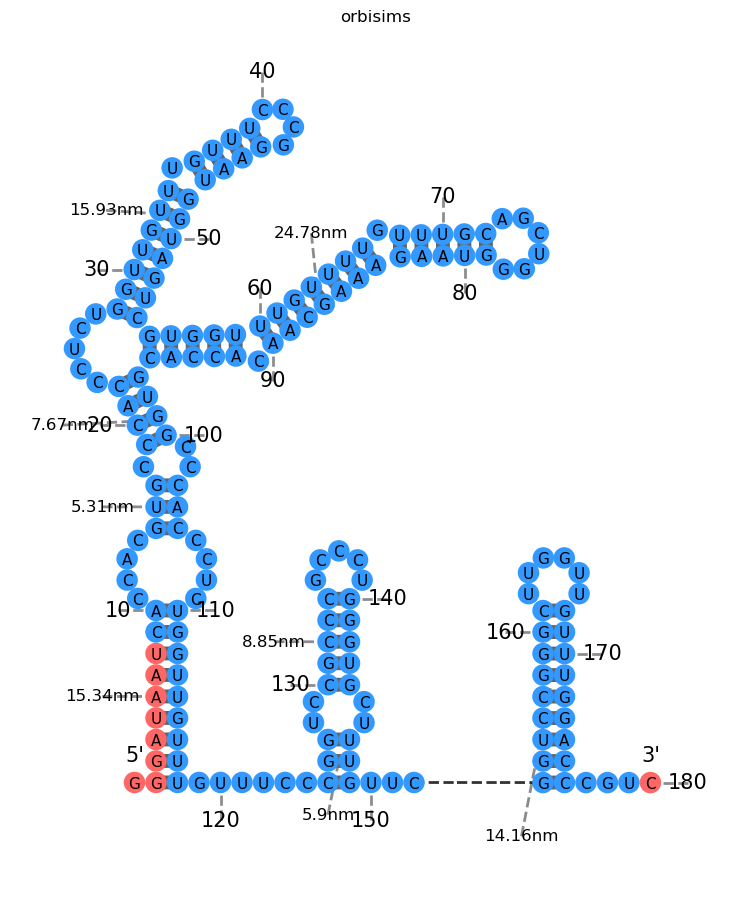

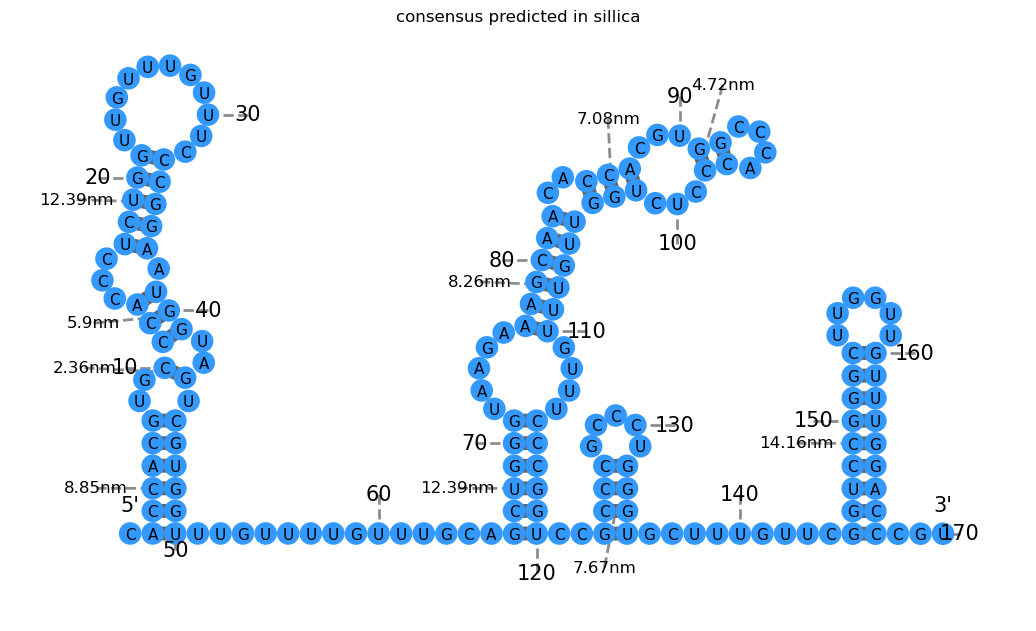

In [62]:
file = files[-1]
f = [(152,5)]
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, predict=False)
colors = ['b' for x in db]
for idx in range(8):
    colors[idx] = 'r'
colors[-1] = 'r'
bases, x, y = create_figure(file, predict=False, colors=colors, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, store_plt_svg=False, add_fake=f, show_plot=True, title=(file.split('/')[-1].strip('.dt'), 0.5, 0.98))
plt.close()
file = files[0]
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, predict=False)
colors = ['b' for x in db]
bases, x, y = create_figure(file, predict=False, colors=colors, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, store_plt_svg=False, add_fake=[], show_plot=True, title=('consensus predicted in sillica', 0.5, 0.98))


In [ ]:
db = predict_structure(seq, salt=0.01)
print(db)
db = predict_structure(seq)
print(db)
db = predict_structure(seq, salt=5)
print(db)
db = predict_structure(seq, salt=10)
print(db)

saving svg/pdf as /home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_consensus_predicted_structure.pdf


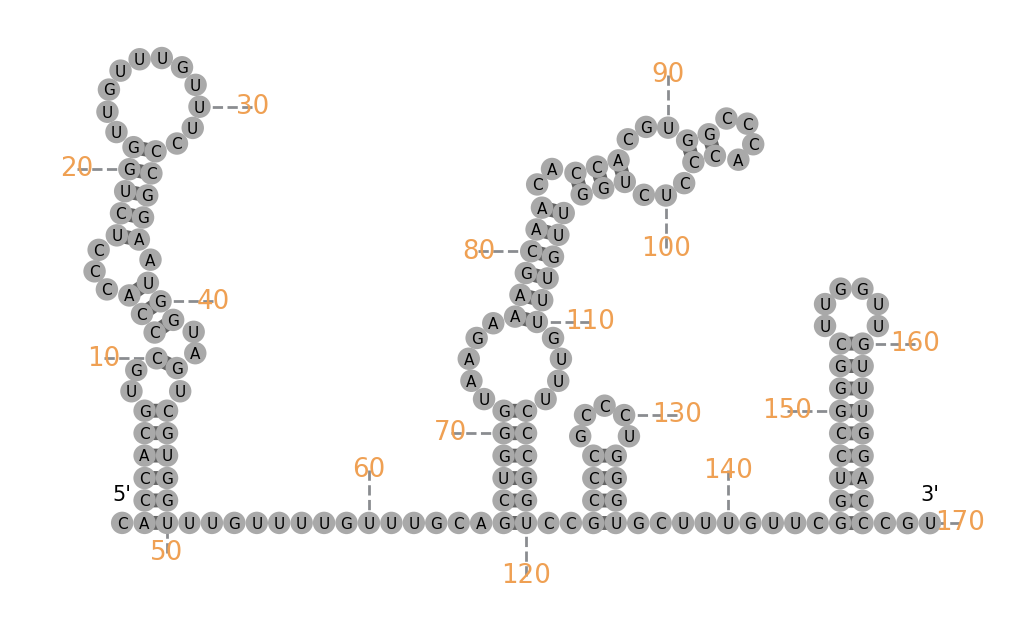

In [8]:
file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt'
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt'
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
colors = ['grey' for _ in db]
# for x in list(range(8))+[len(db)-1]:
#     colors[x] = (255, 22, 22)
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_consensus_predicted_structure.pdf'
overwrite_colors = ([x for x in range(8)]+[len(db)-1], (255, 22, 22))

x = create_figure(file, predict=False, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, segment_lenghts=False, colors=colors, file_name=store_path, store_plt_svg=True)

180
saving svg/pdf as /home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted1.png


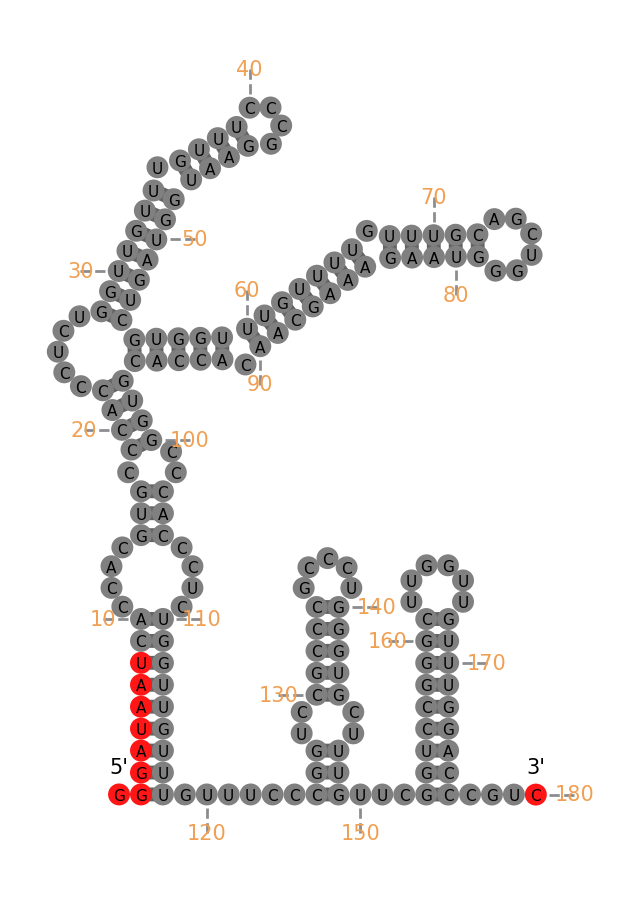

In [74]:
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt'
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt'
file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure1_from_ct.dt'
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
colors = ['grey' for _ in db]
for x in list(range(8))+[len(db)-1]:
    colors[x] = (255, 22, 22)
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted1.png'
overwrite_colors = ([x for x in range(8)]+[len(db)-1], (255, 22, 22))
x = create_figure(file, predict=False, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, segment_lenghts=False, colors=colors, file_name=store_path, store_plt_svg=True, add_fake=[])

saving svg/pdf as /home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted2.pdf


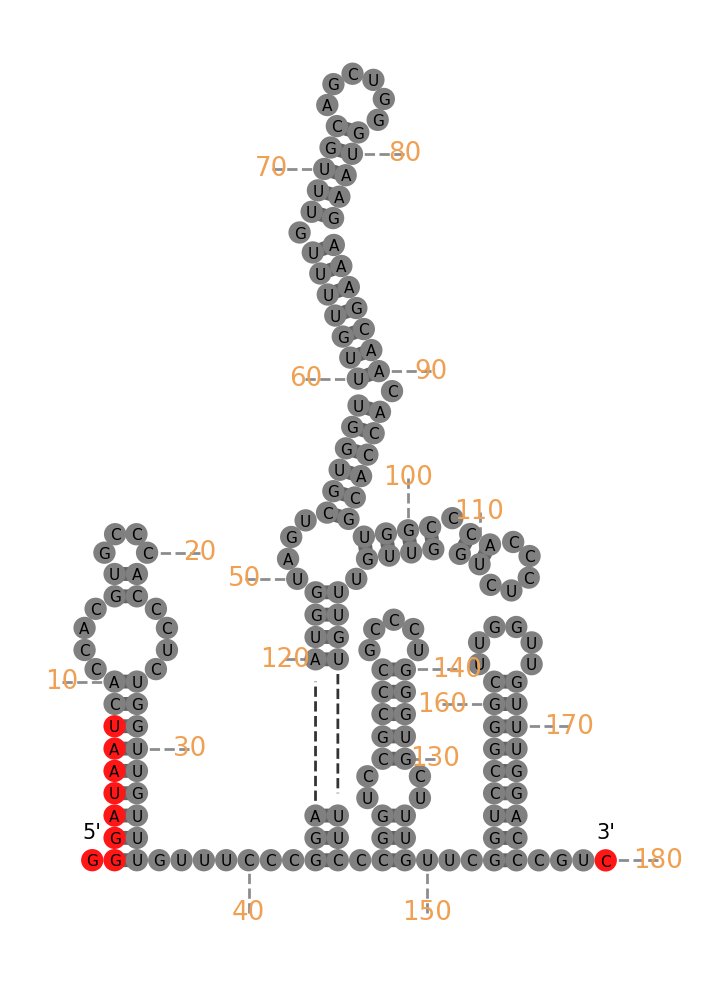

In [6]:
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt'
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt'
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['svg.fonttype'] = 'none'

file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure2_from_ct.dt'
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
colors = ['grey' for _ in db]
for x in list(range(8))+[len(db)-1]:
    colors[x] = (255, 22, 22)
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted2.pdf'
overwrite_colors = ([x for x in range(8)]+[len(db)-1], (255, 22, 22))
x = create_figure(file, predict=False, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, segment_lenghts=False, colors=colors, file_name=store_path, store_plt_svg=True, add_fake=[(45,6,'('),(120,6,')')])

energy -57.29999923706055
saving svg/pdf as /home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted_sequence_RNAstructure.pdf


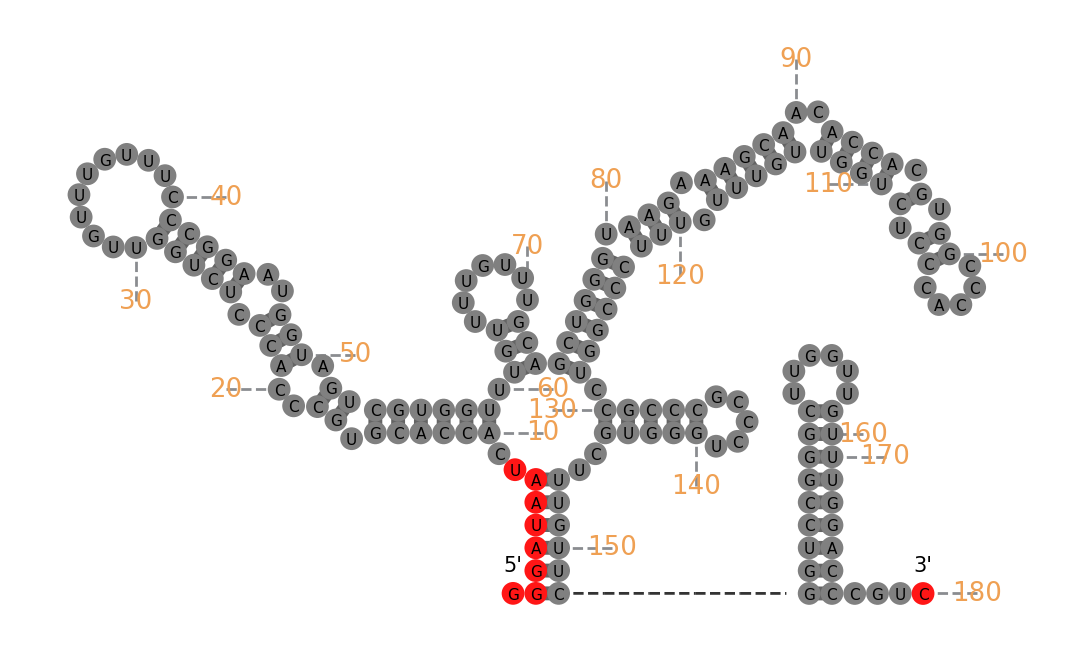

In [7]:
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_Orbi_predicted_sequence_RNAstructure.pdf'
x = create_figure(file, predict=True, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, segment_lenghts=False, colors=colors, file_name=store_path, store_plt_svg=True, add_fake=[(152,10)])

In [ ]:
file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure2_from_ct_removed_cryo-linker.dt'
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_alternative_structure2_from_ct_removed_cryo-linker.png'
x = create_figure(file, predict=True, show_energies=False, energies_individual=False, large_mode=True, numbering=10, custom_line=True, segment_lenghts=False, colors=colors, file_name=store_path, store_plt_svg=True, add_fake=[])

In [ ]:
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/CentroidFold.dt'
# file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/orbisims.dt'
plt.rcParams['svg.fonttype'] = 'none'
file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/alternative_structure2_from_ct.dt'
final_list, final_str_list, seq, db, structures = ct_to_paired_list_count_all(file, None)
colors = ['grey' for _ in db]
for x in list(range(8))+[len(db)-1]:
    colors[x] = (255, 22, 22)
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_orbi_mapped_to_hist.svg'
overwrite_colors = ([x for x in range(8)]+[len(db)-1], (255, 22, 22))
x = create_figure(file, predict=False, show_energies=True, energies_individual=False, large_mode=True, numbering=0, custom_line=True, segment_lenghts=True, colors=colors, file_name=store_path, store_plt_svg=True, add_fake=[(45,6,'('),(120,6,')')], color_map=True, overwrite_colors=overwrite_colors)

171
saving svg/pdf as /home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_mfold1.svg


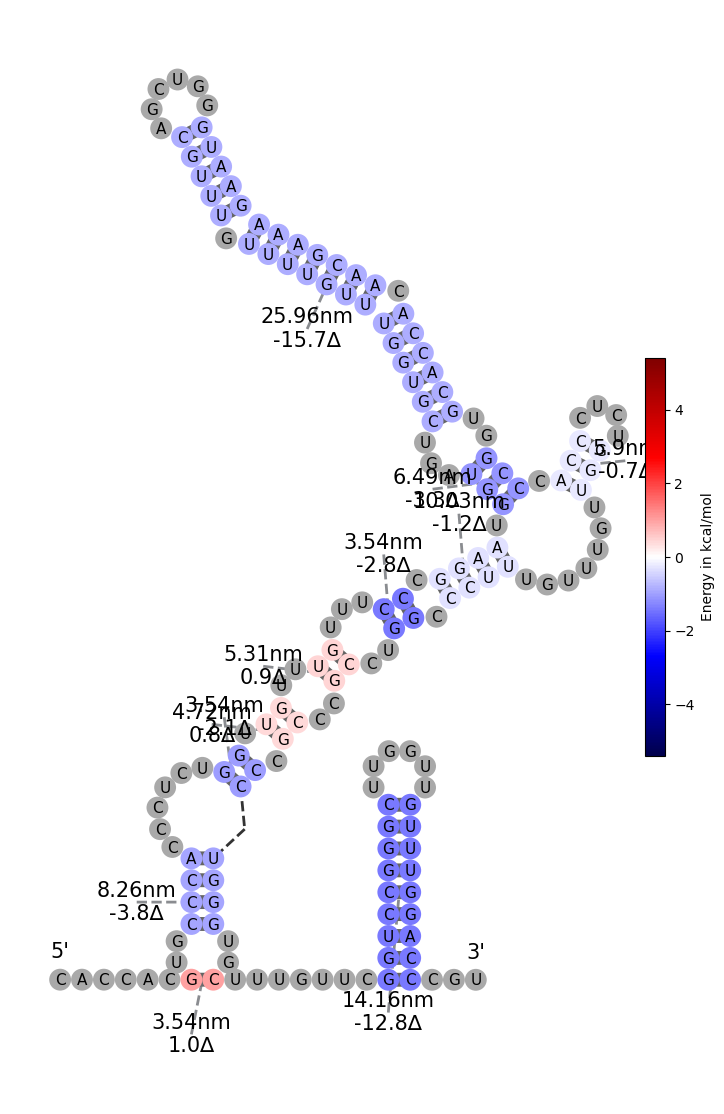

In [95]:
file = '/home/dwarrel/Documents/data/Arenavirus/mfold_pages/GGV-S-IGR-presentation/dots/1.dt'
store_path = '/home/dwarrel/projects/final_thesis/IGR/figures_2/tmp/S_mfold1.svg'
plt.rcParams['svg.fonttype'] = 'none'
x = create_figure(file, predict=False, show_energies=True, energies_individual=False, large_mode=True, numbering=0, custom_line=True, segment_lenghts=True, file_name=store_path, store_plt_svg=True, color_map=True, add_fake=[(130,3)])